In [1]:
import pandas as pd

metadata = pd.read_csv("ESC-50-master/meta/esc50.csv")

metadata.head()

animal_categories = [
    "dog",
    "rooster",
    "pig",
    "cow",
    "frog",
    "cat",
    "hen",
    "insects",
    "sheep",
    "crow"
]

animal_metadata = metadata[
    metadata["category"].isin(animal_categories)
].copy()

print(animal_metadata["category"].value_counts())

category
dog        40
crow       40
sheep      40
frog       40
cow        40
insects    40
hen        40
pig        40
rooster    40
cat        40
Name: count, dtype: int64


In [2]:
import pandas as pd
import librosa
from pathlib import Path

audio_path = "ESC-50-master/audio"
data = []

# loading up audio files and extracting features
for _, row in animal_metadata.iterrows():
    filename = row["filename"]
    category = row["category"]
    filepath = f"{audio_path}/{filename}"
    y, sr = librosa.load(filepath, sr=None)

    rms = librosa.feature.rms(y=y)
    zcr = librosa.feature.zero_crossing_rate(y)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)

    data.append({
        "filename": filename,
        "category": category,
        "rms_mean": rms.mean(),
        "zcr_mean": zcr.mean(),
        "centroid_mean": centroid.mean(),
        "bandwidth_mean": bandwidth.mean()
    })

df = pd.DataFrame(data)

print(df.head())

           filename category  rms_mean  zcr_mean  centroid_mean  \
0  1-100032-A-0.wav      dog  0.007518  0.007329     273.927703   
1  1-103298-A-9.wav     crow  0.123869  0.041329    2675.116865   
2  1-110389-A-0.wav      dog  0.006422  0.002298     183.951009   
3  1-121951-A-8.wav    sheep  0.009328  0.020001    1286.551587   
4   1-15689-A-4.wav     frog  0.042017  0.076411    5168.434669   

   bandwidth_mean  
0      255.475244  
1     3530.183905  
2      322.674676  
3     2400.220021  
4     4754.908980  


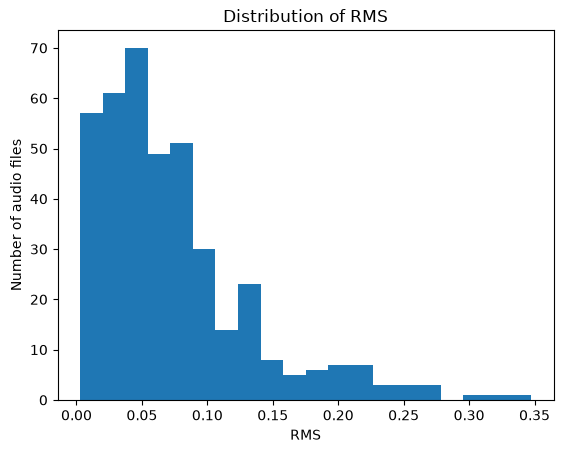

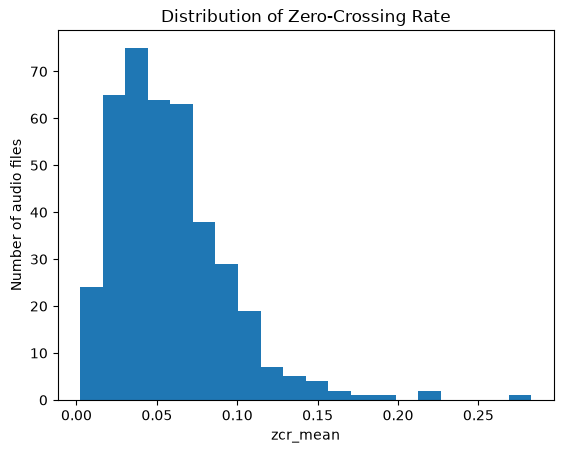

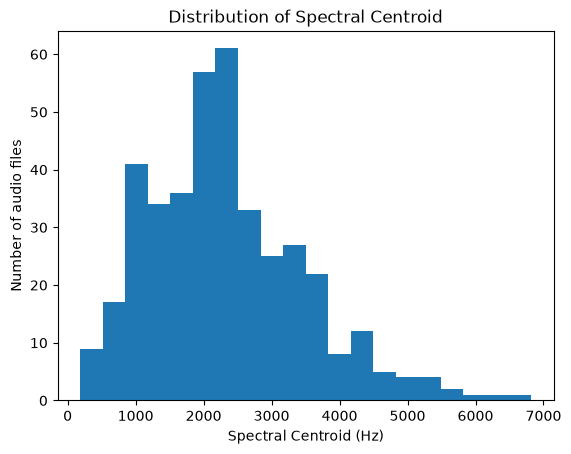

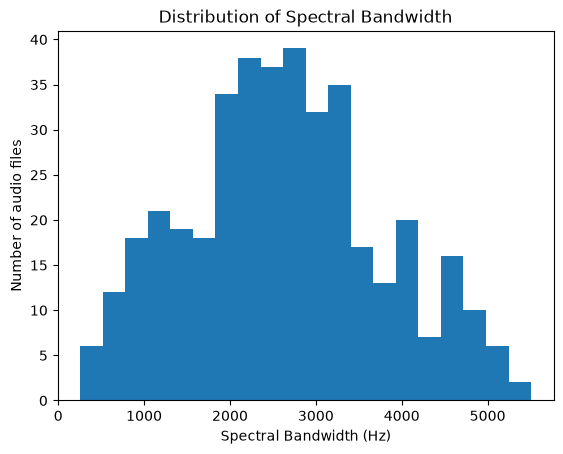

In [3]:
import matplotlib.pyplot as plt

# analyzing spread of data per feature
plt.hist(df["rms_mean"], bins=20)
plt.xlabel("RMS")
plt.ylabel("Number of audio files")
plt.title("Distribution of RMS")
plt.show()

plt.hist(df["zcr_mean"], bins=20)
plt.xlabel("zcr_mean")
plt.ylabel("Number of audio files")
plt.title("Distribution of Zero-Crossing Rate")
plt.show()

plt.hist(df["centroid_mean"], bins=20)
plt.xlabel("Spectral Centroid (Hz)")
plt.ylabel("Number of audio files")
plt.title("Distribution of Spectral Centroid")
plt.show()

plt.hist(df["bandwidth_mean"], bins=20)
plt.xlabel("Spectral Bandwidth (Hz)")
plt.ylabel("Number of audio files")
plt.title("Distribution of Spectral Bandwidth")
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler

# scale features
X = df[
    ["rms_mean",
     "zcr_mean",
     "centroid_mean",
     "bandwidth_mean"
    ]
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

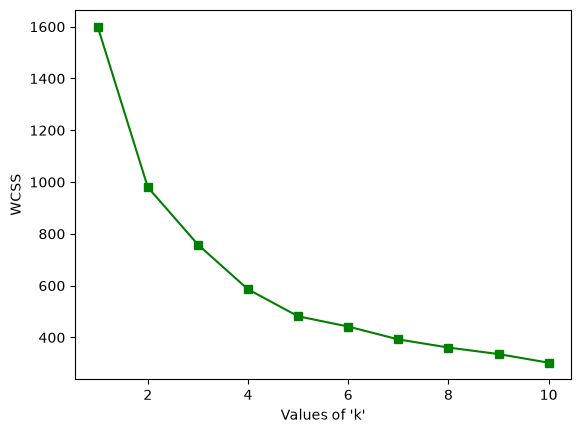

In [5]:
from sklearn.cluster import KMeans

# elbow method to determine best k value
wcss = {} 
for i in range(1, 11): 
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X_scaled) 
    wcss[i] = kmeans.inertia_
    
plt.plot(wcss.keys(), wcss.values(), 'gs-')
plt.xlabel("Values of 'k'")
plt.ylabel('WCSS')
plt.show()

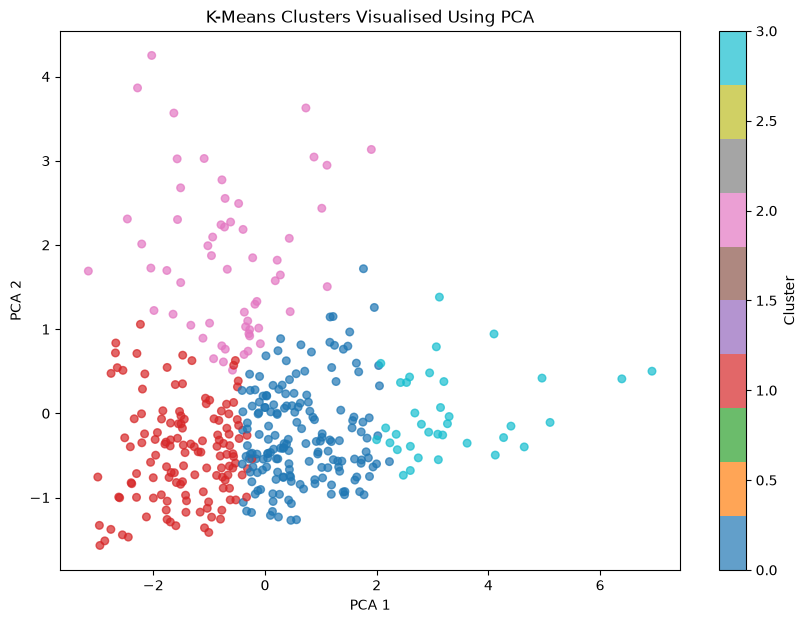

In [6]:
from sklearn.decomposition import PCA

# improve visualisation of clusters using pca
kmeans=KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)

pca=PCA(n_components=2)

reduced_X=pd.DataFrame(data=pca.fit_transform(X_scaled),columns=['PCA1','PCA2'])

reduced_X["cluster"] = kmeans.labels_

plt.figure(figsize=(10, 7))

plt.scatter(
    reduced_X["PCA1"],
    reduced_X["PCA2"],
    c=reduced_X["cluster"],
    cmap="tab10",
    s=30,
    alpha=0.7
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters Visualised Using PCA")

plt.colorbar(label="Cluster")
plt.show()

In [7]:
df["cluster"] = kmeans.labels_ 
pd.crosstab(df["category"], df["cluster"])

cluster,0,1,2,3
category,,,,
cat,23,12,3,2
cow,10,15,13,2
crow,23,11,5,1
dog,11,25,4,0
frog,21,9,8,2
hen,19,8,6,7
insects,19,5,1,15
pig,19,7,13,1
rooster,9,27,2,2


In [8]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, kmeans.labels_)

print(score)

0.31907634293275416


In [9]:
loadings = pd.DataFrame(
    pca.components_,
    columns=["RMS", "ZCR", "Centroid", "Bandwidth"],
    index=["PC1", "PC2"]
)

print(loadings)

          RMS       ZCR  Centroid  Bandwidth
PC1 -0.160124  0.533575  0.617872   0.554881
PC2  0.975008  0.202123  0.091093  -0.014435
